In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [12]:
def imshow(img):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(16, 9), dpi=150)
    plt.imshow(rgb)
    plt.axis("off")
    plt.show()

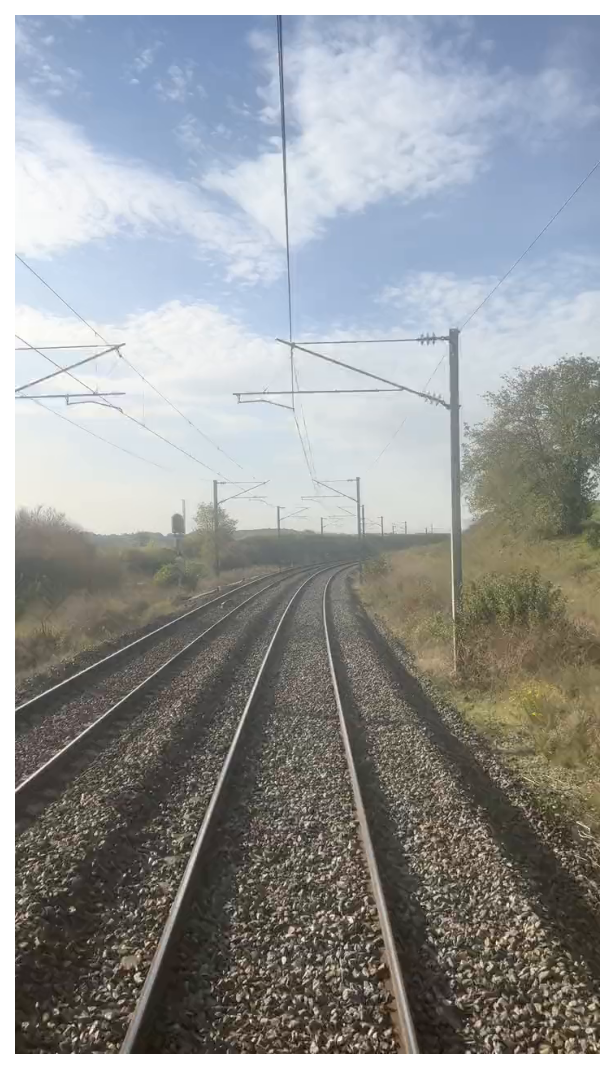

In [13]:
vc = cv2.VideoCapture("/home/oedada/Projects/apps/checkbot/data/train/rails1.mp4")
_, src = vc.read()
imshow(src)

In [36]:
def preprocess(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (7, 7), 0)
    edges = cv2.Canny(blur, 70, 200)

    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi/180,
        threshold=150,
        minLineLength=200,
        maxLineGap=20
    )
    frame = img.copy()
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]

            cv2.line(
                frame,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),  # зелёный
                2             # толщина
            )
    return frame

In [ ]:
vc = cv2.VideoCapture("/home/oedada/Projects/apps/checkbot/data/train/rails1.mp4")
fps = vc.get(cv2.CAP_PROP_FPS)
width = int(vc.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(vc.get(cv2.CAP_PROP_FRAME_HEIGHT))

writer = cv2.VideoWriter(
    "output.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)
i = 0
while True:
    ret, frame = vc.read()
    print(i/fps)
    if not ret:
        continue
    processed_frame = preprocess(frame)
    writer.write(processed_frame)
    i += 1

vc.release()
writer.release()  

KeyboardInterrupt: 